Long-term impact results of PAH toxicity from MPRI2 spill scenarios at Turn Point/Haro Strait

In [1]:
import os
import xarray as xr
import numpy as np
import itertools
import warnings
import pandas as pd
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

warnings.simplefilter('ignore')

### Define scenario and control files

| Scenarios	|	Description |
|-----------|---------------|
| 0	|	no PAHs, 90d closure |
| 1	|	free PAHs (no management) |
| 2 |   30-day fisheries closures |
| 3	|	90-day fisheries closures |
| 4	|	spill containment within 48hrs |
| 5	|	spill containment within 48hrs + 30-day fisheries closures |
| 6	|	spill containment within 48hrs + 90-day fisheries closures |

8 simulations for each scenario
1. winter S winds
1. winter N winds
1. spring opposing winds & currents
1. spring tandem winds & currents
1. summer Fraser + strong winds
1. summer Fraser + weak winds
1. fall strong N winds
1. fall weak winds

### Scenario comparison across fished groups

In [2]:
scenario_palette = sns.color_palette([
#'#A17170',
#'#B39595',
'#863092', 
'#A464AD',
'#C297C8', 
#'#DAC0DE' 
'#2F61A4', 
"#6389BB", 
'#97B0D0',
#'#C0CFE5' lightest
])

In [3]:
simulation_palette = sns.color_palette([

'#EE7733','#CC3311', # SUMMER
'#997700', '#666633', #SPRING
'#EE99AA', '#994455', #FALL
'#6699CC', '#004488', #WINTER
])

In [4]:
sim_hue_order = [
    
    'summer_Fraser_strong_winds', 'summer_Fraser_weak_winds',
    'spring_opposing_winds_currents', 'spring_tandem_winds_currents',
    'fall_strong_N_winds', 'fall_weak_winds', 
    'winter_S_winds', 'winter_N_winds',
]

### Groups for which there are fisheries

In [5]:
dff = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/data_fisheries_bb.csv")

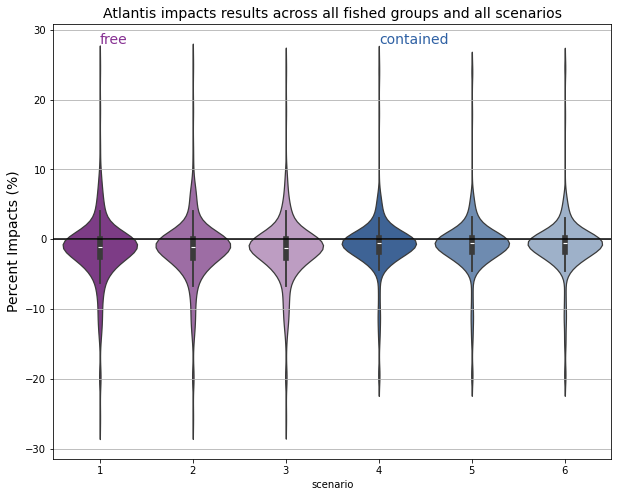

In [6]:
plt.figure(figsize=(10, 8))
plt.grid()
ax = sns.violinplot(dff, x="scenario", y="percent_change", palette=scenario_palette) 
plt.ylabel('Percent Impacts (%)', fontsize = 14)
plt.title('Atlantis impacts results across all fished groups and all scenarios', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.text(0, 28,'free', color='#863092', size=14, )
plt.text(3, 28,'contained', color='#2F61A4', size=14,);

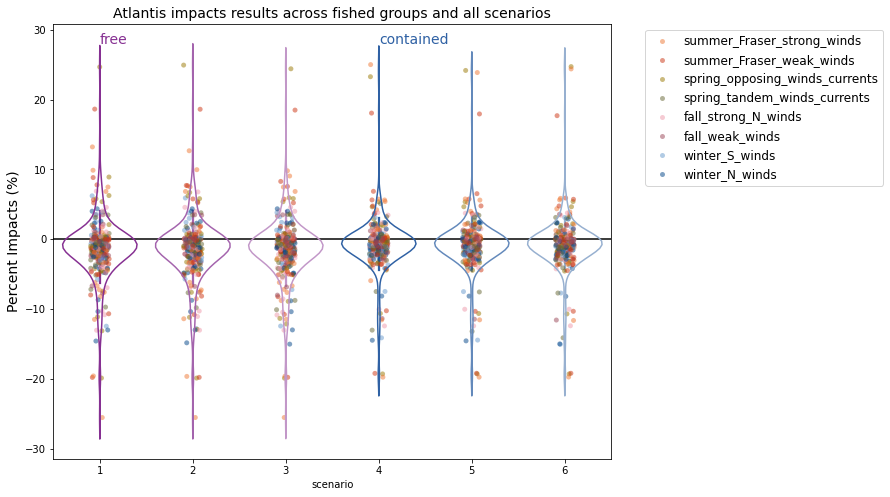

In [7]:
plt.figure(figsize=(10, 8)) 
ax=sns.violinplot(dff, x="scenario", y="percent_change",
    palette=scenario_palette, hue='scenario', fill=False, zorder=10, legend=False) 
sns.stripplot(data=dff, x="scenario",
    y="percent_change", palette=simulation_palette, hue="sim_description", hue_order=sim_hue_order, alpha=0.5, ax=ax)
#plt.ylim(-7.5, 7.5)
plt.ylabel('Percent Impacts (%)', fontsize = 14)
plt.title('Atlantis impacts results across fished groups and all scenarios', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.text(0, 28,'free', color='#863092', size=14, )
plt.text(3, 28,'contained', color='#2F61A4', size=14,)
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=12);

In [8]:
#plt.savefig('Fig-results-fished.png',bbox_inches='tight',dpi=300);

### All groups

In [5]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/data_all_bb.csv")

| Scenarios	|	Description |
|-----------|---------------|
| 0	|	no PAHs with 90d closure|
| 1	|	free PAHs (no management) |
| 2 |   30-day fisheries closures |
| 3	|	90-day fisheries closures |
| 4	|	spill containment within 48hrs |
| 5	|	spill containment within 48hrs + 30-day fisheries closures |
| 6	|	spill containment within 48hrs + 90-day fisheries closures |

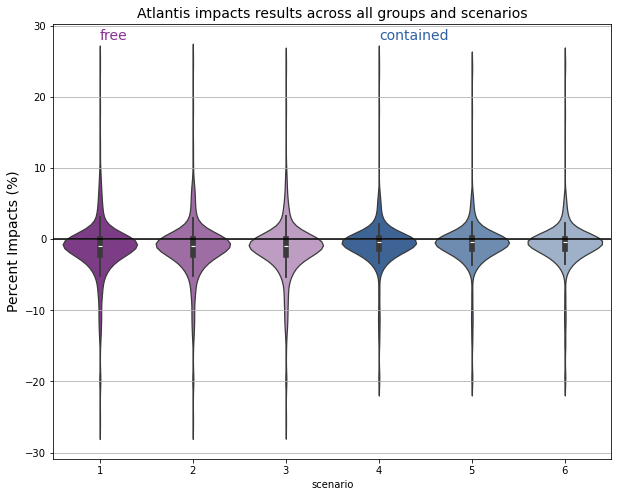

In [10]:
plt.figure(figsize=(10, 8))
plt.grid()
ax = sns.violinplot(df, x="scenario", y="percent_change", palette=scenario_palette) 
plt.ylabel('Percent Impacts (%)', fontsize = 14)
#plt.xticks(rotation=90)
plt.title('Atlantis impacts results across all groups and scenarios', fontsize = 14)
plt.axhline(0, color='k'); 
plt.text(0, 28,'free', color='#863092', size=14)
plt.text(3, 28,'contained', color='#2F61A4', size=14);


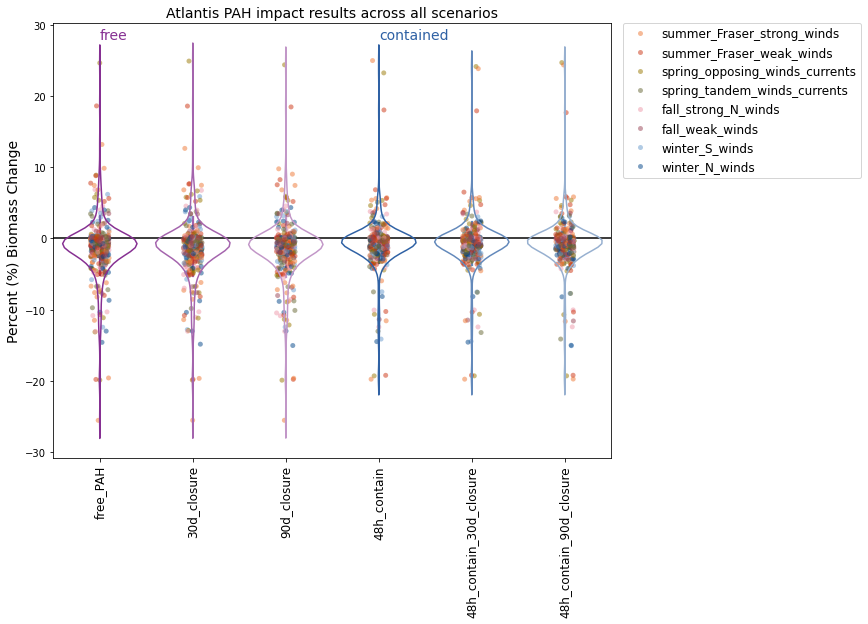

In [39]:
plt.figure(figsize=(10, 8)) 
ax=sns.violinplot(df, x="description", y="percent_change",
    palette=scenario_palette, hue='scenario', fill=False, zorder=10, legend=False) 
sns.stripplot(data=df, x="description",
    y="percent_change", palette=simulation_palette, hue="sim_description", hue_order=sim_hue_order, alpha=0.5, ax=ax)
#plt.ylim(-7.5, 7.5)
plt.ylabel('Percent (%) Biomass Change', fontsize = 14)
plt.title('Atlantis PAH impact results across all scenarios', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.text(0, 28,'free', color='#863092', size=14, )
plt.text(3, 28,'contained', color='#2F61A4', size=14,)
plt.legend(bbox_to_anchor=(1.01, 1.015), fontsize=12)
plt.xlabel(None)
plt.xticks(rotation=90, fontsize=12)
plt.savefig('Fig-results-scenarios.png',bbox_inches='tight',dpi=300);

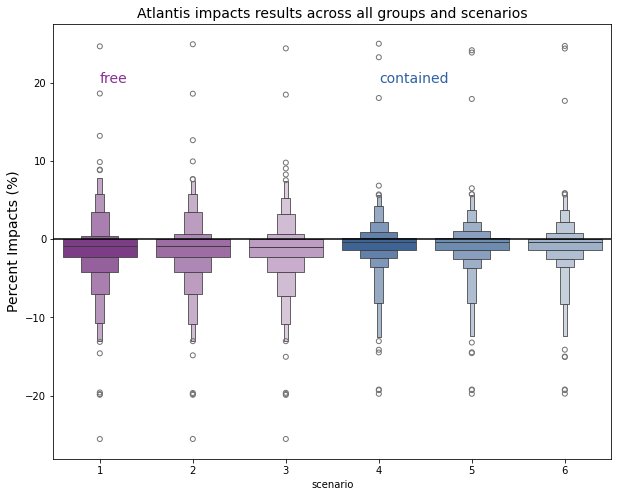

In [12]:
plt.figure(figsize=(10, 8))
ax = sns.boxenplot(df, x="scenario", y="percent_change", palette=scenario_palette) 
plt.ylabel('Percent Impacts (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups and scenarios', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.text(0, 20,'free', color='#863092', size=14,)
plt.text(3, 20,'contained', color='#2F61A4', size=14,);

Boxen plots: innermost box is drawn at the lower and upper fourths, incrementally narrower box is drawn between at the lower and upper eighths, and narrower one still at the lower and upper sixteenths (not applicable on this dataset). Tails show the remaining data that exceed the boxes. See the heatmap to know which functional groups correspond to the tails for the scenarios & simulations shown.

compare seasons

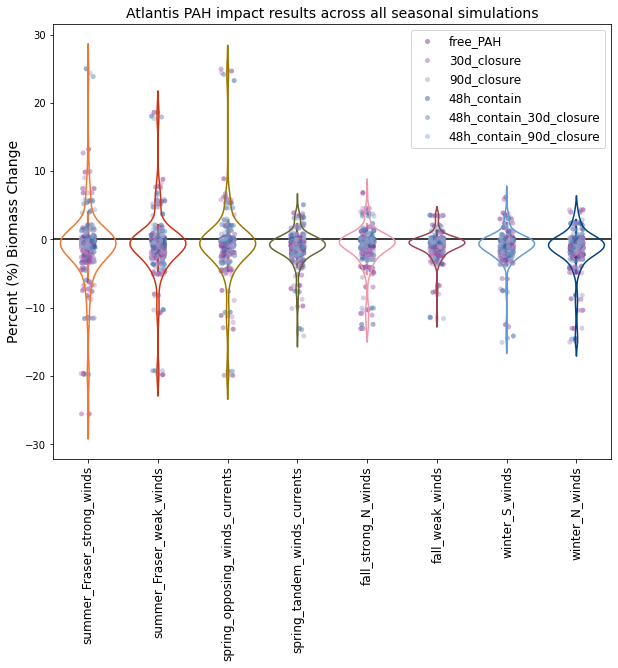

In [7]:
plt.figure(figsize=(10, 8)) 
ax=sns.violinplot(df, x="sim_description", y="percent_change", order=sim_hue_order,
    palette=simulation_palette, hue='sim_description', hue_order = sim_hue_order, fill=False, zorder=10, legend=False) 
sns.stripplot(data=df, x="sim_description", 
    y="percent_change", order=sim_hue_order, palette=scenario_palette, hue="description", alpha=0.5, ax=ax)
#plt.ylim(-7.5, 7.5)
plt.ylabel('Percent (%) Biomass Change', fontsize = 14)
plt.title('Atlantis PAH impact results across all seasonal simulations', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.xticks(rotation=90, fontsize=12)
plt.xlabel(None)
plt.legend(bbox_to_anchor=(1, 1), fontsize=12)
plt.savefig('Fig-results-seasons.png',bbox_inches='tight',dpi=300);

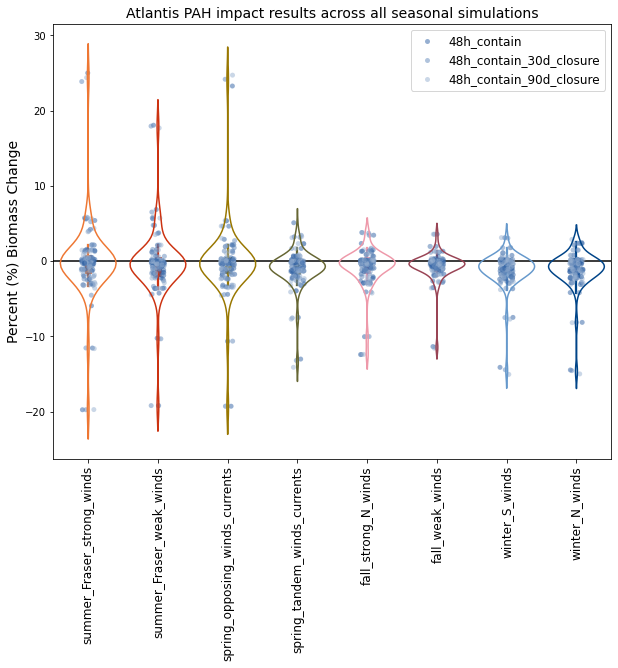

In [8]:
df_plot = df[(df['description'].str.contains('48h_contain'))]
plt.figure(figsize=(10, 8)) 
ax=sns.violinplot(df_plot, x="sim_description", y="percent_change", order=sim_hue_order,
    palette=simulation_palette, hue='sim_description', hue_order = sim_hue_order, fill=False, zorder=10, legend=False) 
sns.stripplot(data=df_plot, x="sim_description", 
    y="percent_change", order=sim_hue_order, palette=scenario_palette[3:6], hue="description", alpha=0.5, ax=ax)
#plt.ylim(-7.5, 7.5)
plt.ylabel('Percent (%) Biomass Change', fontsize = 14)
plt.title('Atlantis PAH impact results across all seasonal simulations', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.xticks(rotation=90, fontsize=12)
plt.xlabel(None)
plt.legend(bbox_to_anchor=(1, 1), fontsize=12)
plt.savefig('Fig-results-seasons-contained.png',bbox_inches='tight',dpi=300);